In [ ]:
%pip install tqdm matplotlib --quiet

In [1]:
import rsa_oaep

In [2]:
(n, e, d) = rsa_oaep.generate_rsa_key()
message = "Ana are mere".encode()

ciphertext = rsa_oaep.rsa_oaep_encrypt(message, n, e)
print(f"Message: {message}")
print(f"Ciphertext: {ciphertext}")

Message: b'Ana are mere'
Ciphertext: b'*)\xa0y&\x86{\x95\xadt\xe2\x0c\xde\xcak\x1bU\x1b_\x8bC\xe8\rAb\xf9\xe8\xdf"\x80\xd1\x152k\\\xb9\x9a\xf1\xd0\xef\x1b\xd1\xef\xd0~\x94o,\x15\xb3x\x88\xb1\xd6\xbc\x11\x9d\xfb\x01\x94Z\x19M\xad\xd8\xcfe\x85\xd8J!\xc5T\xfb\xc6\n\xae\xc5H#6gNP~\xbe\x82\xa8\x9c\x00\x87\xb0\xdf\x07al\xcc\xfe\xde\xa9\xacH0Pw\x95\xc5#a\x9eu5Y\xe1@\xd9\xee\x85q\xc1\xd6\xc8\xdf\xa3+\xa1\xaa\x87%\x19\x06\xb9q\xcb\xcaM~\xf6\xff\xd9\x1f\xee\xab\'\x8d\x98\tD\x05\xa0\x1f\xb9q<\xef\x08\xdc\xcbw\x06\x13\xb8d\x10\x1f\xda\xb2\xe8\xf3\x83\xdb>\x10\xeb\xafn#\x11\xa7\xf4L\x04\xf4\xb7\xe9\x03\x1e\x91\xd2\x84\xfe\xdf\xddM\x1d=$\xc0O\xc4\xf6p\xf3\xf9?\r\xc8\xcf@\x1a\xc1\x88\xed]X\xdf\xdbcd\x8d\xa1\x10\x80K\xbd\xb2}\xd3\x9a\xa2\xd8\xab\xc6\\I[?\xff\x0c;\xd4\'\xbb\xd5\x99\xcd\xbbK7\x18H\x8c\x19w\xf0\xe4Z\x11\xf2\x0c\xa1T\x957\xfb.\x06\x90\x1a\x94\x82\xdc\xb7\x11\xb1\x04\xc0\xc1H4\xb98I>S\x8d\xe1\xe5\xb2\xd3\xf9\xd7J\xbeq\x15\x8cdk\x88\x17\x94\xbe=\xea\xf0\xee\xa4\x1b\x9c\xff_\xa3\x8f\xc7B9\xd

In [3]:
decrypted_message = rsa_oaep.rsa_oaep_decrypt(ciphertext, n, d)
print(f"Decrypted message: {decrypted_message}")

Decrypted message: b'Ana are mere'


In [4]:
maleated_ciphertext = bytearray(ciphertext)
maleated_ciphertext[0] ^= 0xff
decrypted_message = rsa_oaep.rsa_oaep_decrypt(maleated_ciphertext, n, d)
print(f"Decrypted message: {decrypted_message}")

Decrypted message: None


100%|██████████| 1000/1000 [02:14<00:00,  7.46it/s]


Text(0.5, 0, 'Decryption time (seconds)')

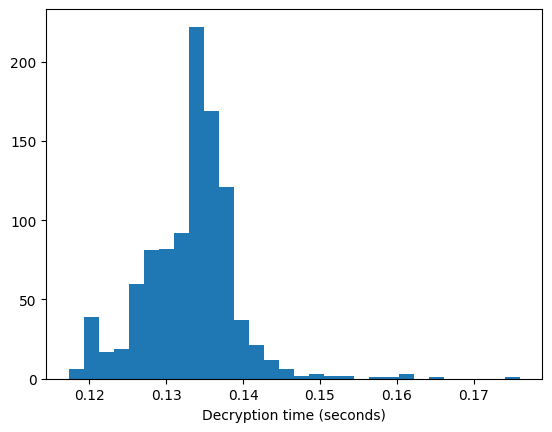

In [5]:
import secrets, time
from tqdm import tqdm
import matplotlib.pyplot as plt

N = 1000
times = []
for i in tqdm(range(N)):
    random_ciphertext = secrets.token_bytes(len(ciphertext))
    start = time.perf_counter()
    decrypted_message = rsa_oaep.rsa_oaep_decrypt(random_ciphertext, n, d)
    end = time.perf_counter()
    times.append(end - start)

plt.hist(times, bins=30)
plt.xlabel("Decryption time (seconds)")

100%|██████████| 1000/1000 [02:08<00:00,  7.80it/s]


Text(0.5, 0, 'Decryption time (seconds)')

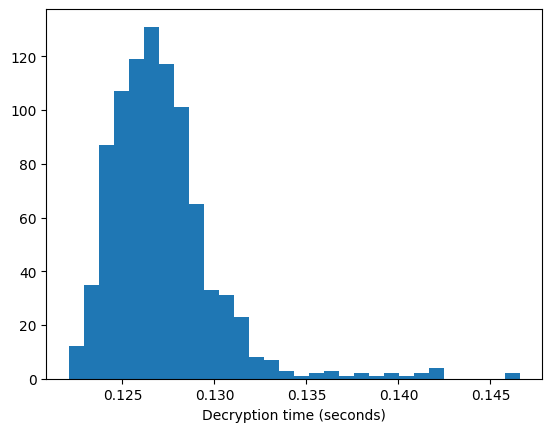

In [6]:
N = 1000
times = []
for i in tqdm(range(N)):
    random_ciphertext = secrets.token_bytes(len(ciphertext))
    start = time.perf_counter()
    decrypted_message = rsa_oaep.rsa_oaep_decrypt(random_ciphertext, n, d)
    end = time.perf_counter()
    if i >= 100:
        times.append(end - start)

plt.hist(times, bins=30)
plt.xlabel("Decryption time (seconds)")

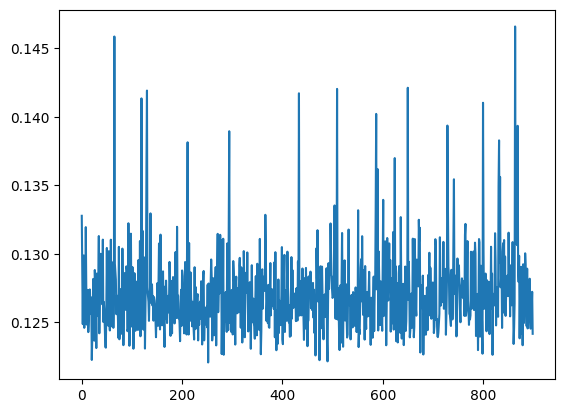

In [7]:
plt.plot(times)